In [7]:
pip install pandas scikit-learn gymnasium matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load uploaded file
df = pd.read_csv('Evil_Twin_30.csv', low_memory=False)

# 1. Feature Selection (The Signal Fingerprint)
cols = ['radiotap.dbm_antsignal', 'frame.time_delta', 'wlan.fixed.timestamp', 'wlan.seq', 'Label']
data = df[cols].copy()

# 2. Data Cleaning: Convert to numeric and fill NaNs (common in Wi-Fi captures)
for col in cols[:-1]:
    data[col] = pd.to_numeric(data[col], errors='coerce')
data = data.fillna(0)

# 3. Label Encoding: 'Normal' -> 0, 'EvilTwin' -> 1
le = LabelEncoder()
data['Label'] = le.fit_transform(data['Label'])

# 4. Scaling features for the Agent
scaler = StandardScaler()
X = scaler.fit_transform(data.iloc[:, :-1])
y = data['Label'].values

print(f"Dataset Processed: {X.shape[0]} packets ready for testing.")

Dataset Processed: 49999 packets ready for testing.


In [3]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces

class AWID3BanditEnv(gym.Env):
    def __init__(self, features, labels):
        super(AWID3BanditEnv, self).__init__()
        self.features = features
        self.labels = labels
        self.current_step = 0
        self.action_space = spaces.Discrete(2) # 0: Normal, 1: EvilTwin
        
    def step(self, action):
        actual = self.labels[self.current_step]
        # Reward logic: Correct classification = +1, Wrong = -10 (Security priority) just to make math easy ;)
        reward = 1.0 if action == actual else -10.0
        
        self.current_step += 1
        done = self.current_step >= len(self.labels)
        return self.features[self.current_step-1], reward, done, False, {}
    
    def reset(self, seed=None):
        self.current_step = 0
        return self.feature[0], {}
    
class UCB:
    def __init__(self, n_arms=2):
        self.counts = np.zeros(n_arms)
        self.values = np.zeros(n_arms)
        
    def select(self, t):
        if 0 in self.counts: return np.where(self.counts == 0)[0][0]
        # UCB Formula
        return np.argmax(self.values + np.sqrt((2 * np.log(t)) / (self.counts + 1e-5)))

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]

Processed 10000 packets.
Classes found in this run: ['Evil_Twin', 'Normal']

Detailed Report
              precision    recall  f1-score   support

   Evil_Twin       0.00      0.00      0.00        32
      Normal       1.00      1.00      1.00      9967

    accuracy                           1.00      9999
   macro avg       0.50      0.50      0.50      9999
weighted avg       0.99      1.00      1.00      9999



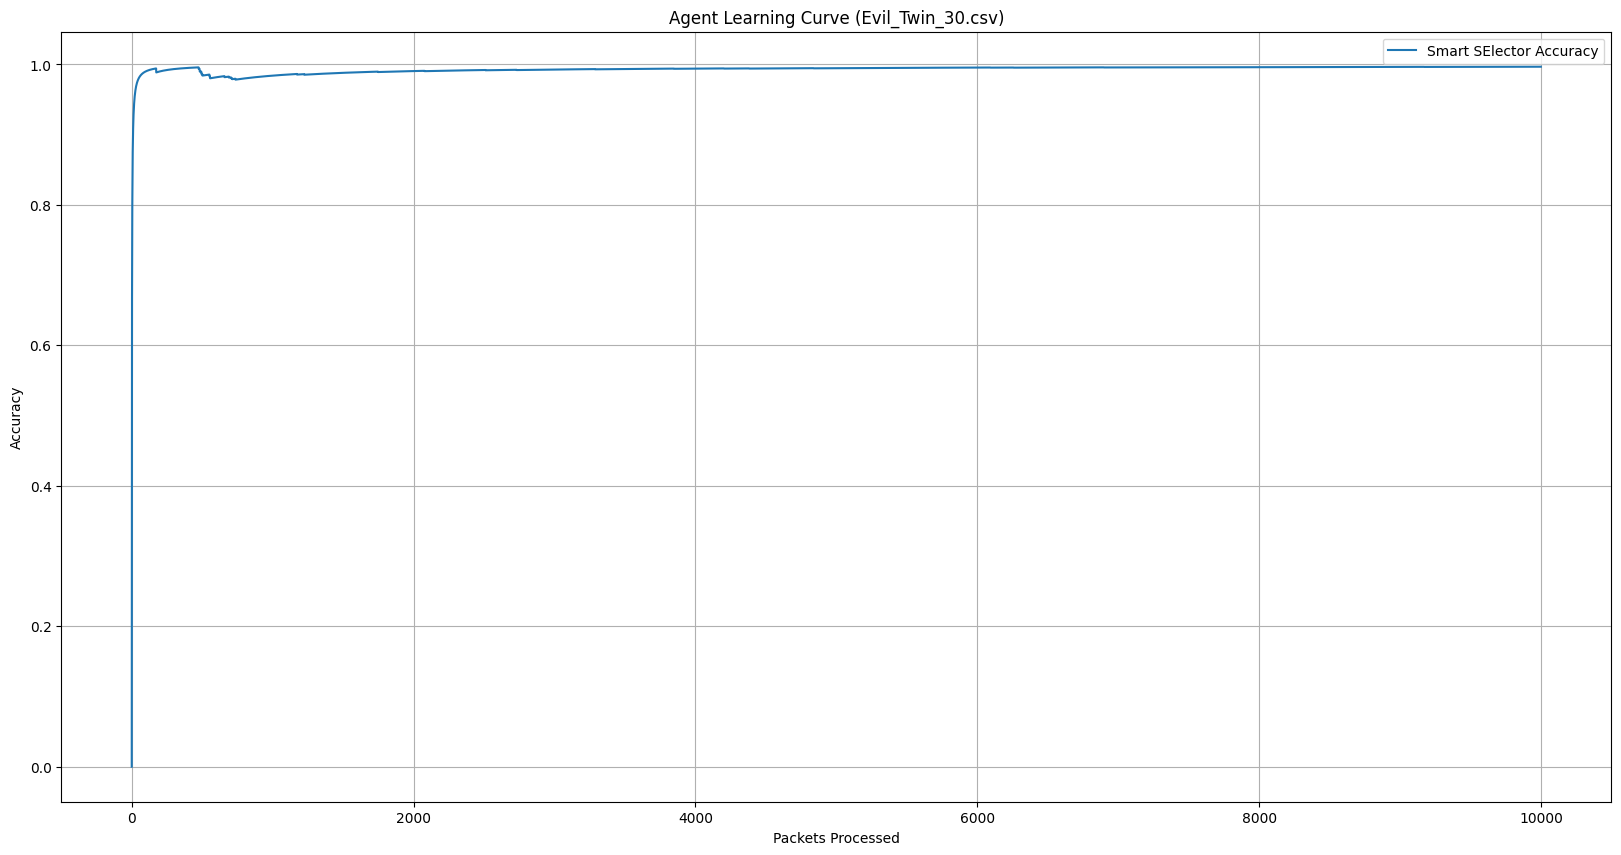

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

env = AWID3BanditEnv(X,y)
agent = UCB()
history = []

# Processing more packets to ensure we hit the 'Evil Twin' section of our CSV
# Increase 5000 to a larger number if our CSV has the attack later in the file
test_limit = min(len(X), 10000)

for t in range(1, test_limit):
    action = agent.select(t)
    _, reward, done, _, _ = env.step(action)
    agent.update(action, reward)
    history.append({'action': action, 'actual': y[t-1]})
    
# Creating results
res = pd.DataFrame(history)

# Trying a safety thing but not yet sure :/
unique_data = np.unique(res['actual'])
current_target = [le.classes_[i] for i in unique_data]

print(f"Processed {test_limit} packets.")
print(f"Classes found in this run: {current_target}")

# Still working on it because something is wrong with recall part
print("\nDetailed Report")
print(classification_report(
    res['actual'],
    res['action'],
    labels=unique_data,
    target_names=current_target
))

# Trying to plot
res['accuracy'] = (res['action'] == res['actual']).expanding().mean()
plt.figure(figsize=(20,10))
plt.plot(res['accuracy'], label='Smart SElector Accuracy')
plt.title("Agent Learning Curve (Evil_Twin_30.csv)")
plt.xlabel("Packets Processed")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()